In [1]:
# ── ensure the project venv and src/ are on the path ─────────────────────────
import sys
from pathlib import Path

SRC = str(Path('..').resolve() / 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

In [2]:
import warnings
warnings.filterwarnings('ignore')

import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from autogluon.tabular import TabularPredictor
from sklearn.metrics import (
    average_precision_score, confusion_matrix,
    f1_score, precision_score, precision_recall_curve,
    recall_score, roc_auc_score, roc_curve,
)

from data_loader import load_raw, DATA_PATH
from preprocess  import run_pipeline

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams['figure.dpi'] = 120

PROJECT_ROOT = Path('..').resolve()
MODELS_DIR   = PROJECT_ROOT / 'models'
RESULTS_DIR  = PROJECT_ROOT / 'results'

raw_df = load_raw(DATA_PATH)
train_df, test_df = run_pipeline(raw_df)

predictor = TabularPredictor.load(str(MODELS_DIR))

y_proba = predictor.predict_proba(test_df)
y_score = y_proba[1].values
y_true  = test_df['stroke'].values

print(f'Test set  : {len(test_df)} rows  |  Positive rate: {y_true.mean()*100:.1f}%')
print(f'Best model: {predictor.model_best}')

Test set  : 1122 rows  |  Positive rate: 13.4%
Best model: WeightedEnsemble_L3


## 1. Metrics Summary

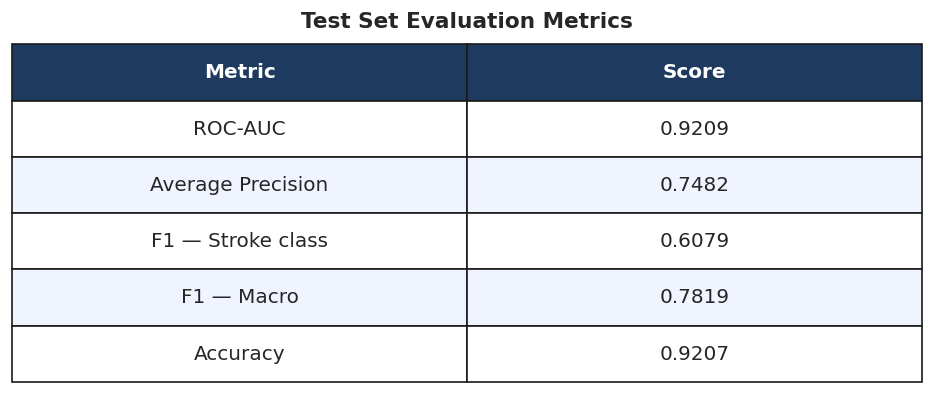

In [3]:
with open(RESULTS_DIR / 'metrics.json') as f:
    metrics = json.load(f)

summary = pd.DataFrame([
    {'Metric': 'ROC-AUC',           'Score': metrics['roc_auc']},
    {'Metric': 'Average Precision', 'Score': metrics['average_precision']},
    {'Metric': 'F1 — Stroke class', 'Score': metrics['f1_stroke']},
    {'Metric': 'F1 — Macro',        'Score': metrics['f1_macro']},
    {'Metric': 'Accuracy',          'Score': metrics['accuracy']},
])

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.axis('off')
tbl = ax.table(cellText=summary.values, colLabels=summary.columns,
               cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1E3A5F')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#F0F4FF' if r % 2 == 0 else 'white')
ax.set_title('Test Set Evaluation Metrics', fontweight='bold', fontsize=13, pad=10)
plt.tight_layout()
plt.show()

## 2. Model Leaderboard

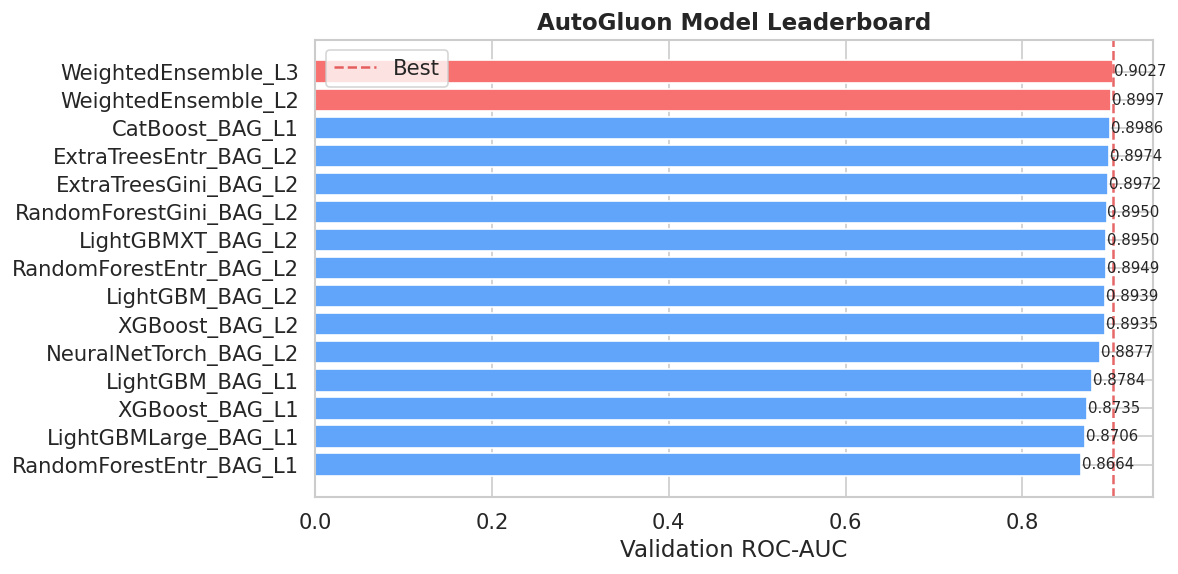

,model,score_val,fit_time,pred_time_val
0,WeightedEnsemble_L3,0.9027,169.0688,1.1191
1,WeightedEnsemble_L2,0.8997,120.9420,0.0633
2,CatBoost_BAG_L1,0.8986,78.4332,0.0113
3,ExtraTreesEntr_BAG_L2,0.8974,137.3312,0.6958
4,ExtraTreesGini_BAG_L2,0.8972,137.3486,0.7011
5,RandomForestGini_BAG_L2,0.8950,137.3919,0.6886
6,LightGBMXT_BAG_L2,0.8950,158.4752,0.5782
7,RandomForestEntr_BAG_L2,0.8949,137.3468,0.6871
8,LightGBM_BAG_L2,0.8939,166.0479,0.5732
9,XGBoost_BAG_L2,0.8935,141.3617,0.6052


In [4]:
lb      = pd.read_csv(RESULTS_DIR / 'leaderboard.csv')
plot_lb = lb.sort_values('score_val', ascending=True).tail(15)
colors  = ['#F87171' if 'Ensemble' in m else '#60A5FA' for m in plot_lb['model']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(plot_lb['model'], plot_lb['score_val'], color=colors, edgecolor='white')
ax.set_xlabel('Validation ROC-AUC')
ax.set_title('AutoGluon Model Leaderboard', fontweight='bold')
ax.axvline(plot_lb['score_val'].max(), color='#DC2626', ls='--', lw=1.5, alpha=0.7, label='Best')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.001, bar.get_y() + bar.get_height() / 2, f'{w:.4f}', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()
display(lb[['model', 'score_val', 'fit_time', 'pred_time_val']].round(4))

## 3. Feature Importance

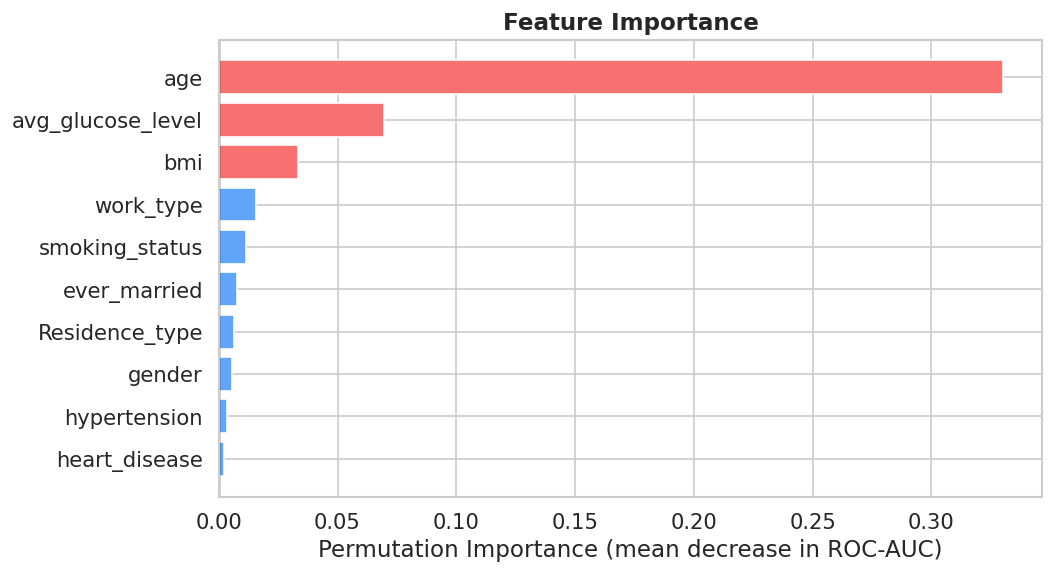

,importance,stddev,p_value,n,p99_high,p99_low
age,0.330151,0.007051,2.494828e-08,5,0.344669,0.315633
avg_glucose_level,0.069454,0.004903,2.959888e-06,5,0.079549,0.059359
bmi,0.033254,0.001600,6.415480e-07,5,0.036549,0.029959
work_type,0.015841,0.001416,7.589798e-06,5,0.018757,0.012925
smoking_status,0.011412,0.001181,1.357344e-05,5,0.013844,0.008980


In [5]:
fi        = pd.read_csv(RESULTS_DIR / 'feature_importance.csv', index_col=0)
fi_sorted = fi.sort_values('importance', ascending=True)
colors    = ['#F87171' if v >= fi_sorted['importance'].quantile(0.75) else '#60A5FA'
             for v in fi_sorted['importance']]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi_sorted.index, fi_sorted['importance'], color=colors, edgecolor='white')
ax.set_xlabel('Permutation Importance (mean decrease in ROC-AUC)')
ax.set_title('Feature Importance', fontweight='bold')
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()
display(fi.sort_values('importance', ascending=False).head(5))

## 4. Score Distribution & Calibration

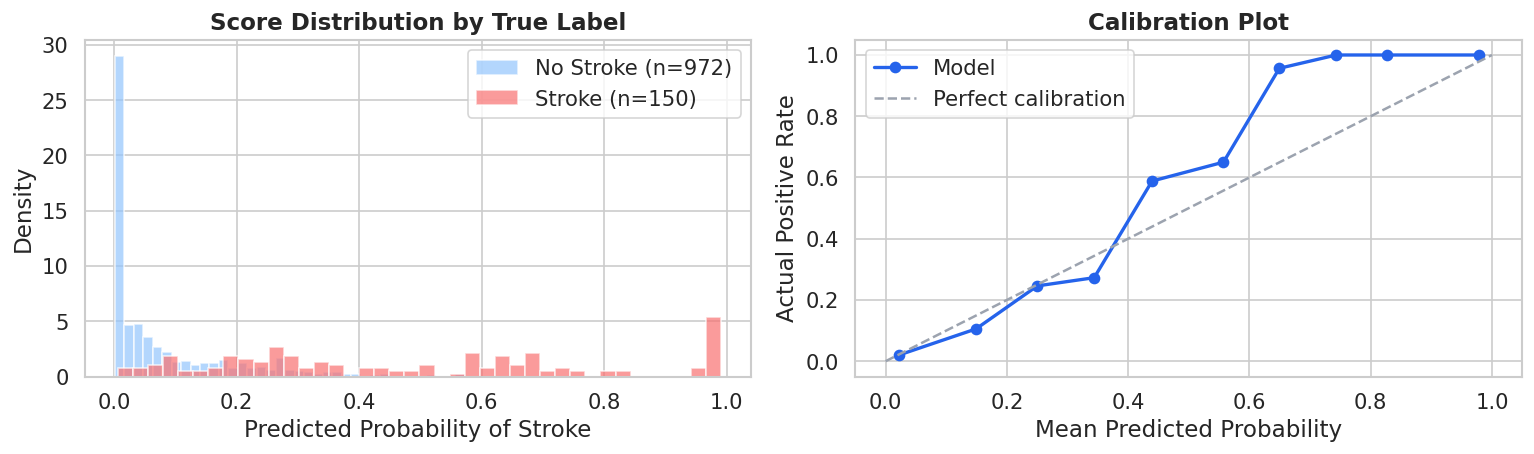

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, name, color in [(0, 'No Stroke', '#93C5FD'), (1, 'Stroke', '#F87171')]:
    mask = y_true == label
    axes[0].hist(y_score[mask], bins=40, alpha=0.7, color=color,
                 label=f'{name} (n={mask.sum()})', edgecolor='white', density=True)
axes[0].set_xlabel('Predicted Probability of Stroke')
axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution by True Label', fontweight='bold')
axes[0].legend()

bins     = np.linspace(0, 1, 11)
bin_idx  = np.clip(np.digitize(y_score, bins) - 1, 0, len(bins) - 2)
bin_pred = np.array([y_score[bin_idx == i].mean() if (bin_idx == i).sum() > 0 else np.nan for i in range(len(bins)-1)])
bin_act  = np.array([y_true[bin_idx == i].mean()  if (bin_idx == i).sum() > 0 else np.nan for i in range(len(bins)-1)])
ok       = ~np.isnan(bin_pred)
axes[1].plot(bin_pred[ok], bin_act[ok], 'o-', color='#2563EB', lw=2, label='Model')
axes[1].plot([0, 1], [0, 1], '--', color='#9CA3AF', label='Perfect calibration')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Actual Positive Rate')
axes[1].set_title('Calibration Plot', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. ROC Curve & Precision-Recall Curve

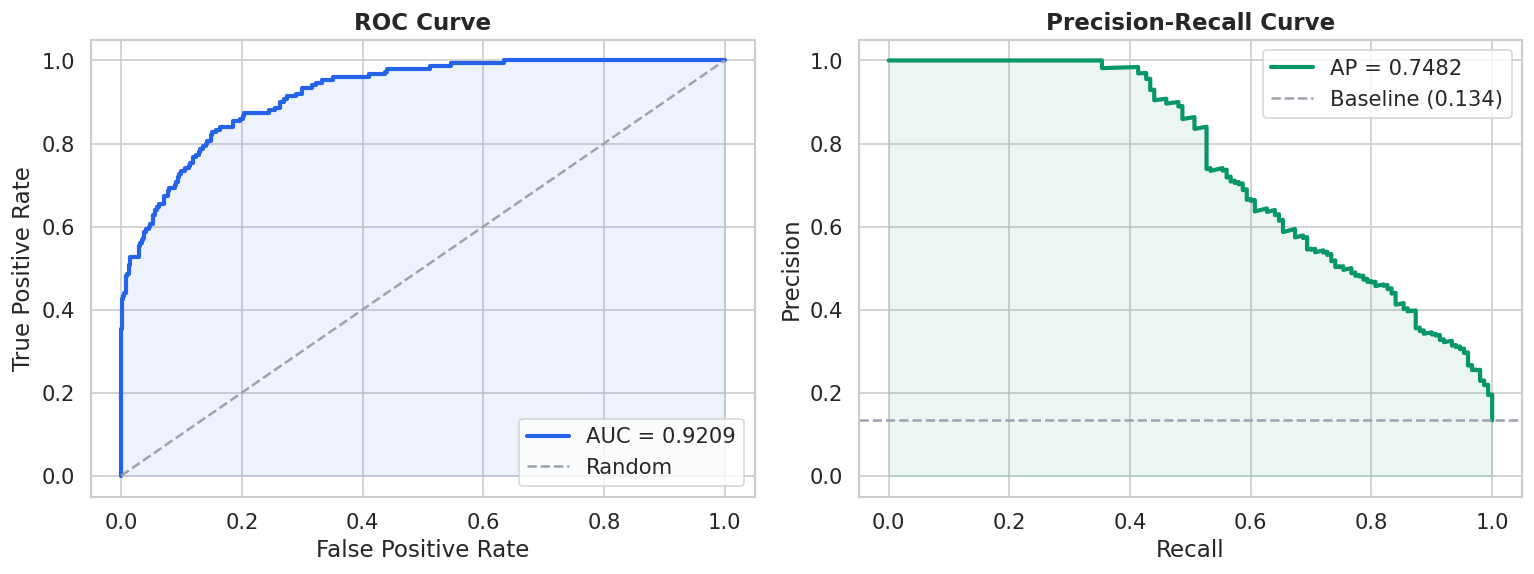

In [7]:
fpr, tpr, _ = roc_curve(y_true, y_score)
auc         = roc_auc_score(y_true, y_score)
prec, rec, _ = precision_recall_curve(y_true, y_score)
ap          = average_precision_score(y_true, y_score)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, color='#2563EB', lw=2.5, label=f'AUC = {auc:.4f}')
axes[0].plot([0,1],[0,1], '--', color='#9CA3AF', lw=1.5, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#2563EB')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(loc='lower right')

axes[1].plot(rec, prec, color='#059669', lw=2.5, label=f'AP = {ap:.4f}')
axes[1].axhline(y_true.mean(), color='#9CA3AF', ls='--', lw=1.5, label=f'Baseline ({y_true.mean():.3f})')
axes[1].fill_between(rec, prec, alpha=0.08, color='#059669')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend(loc='upper right')
plt.tight_layout()
plt.show()

## 6. Threshold Analysis

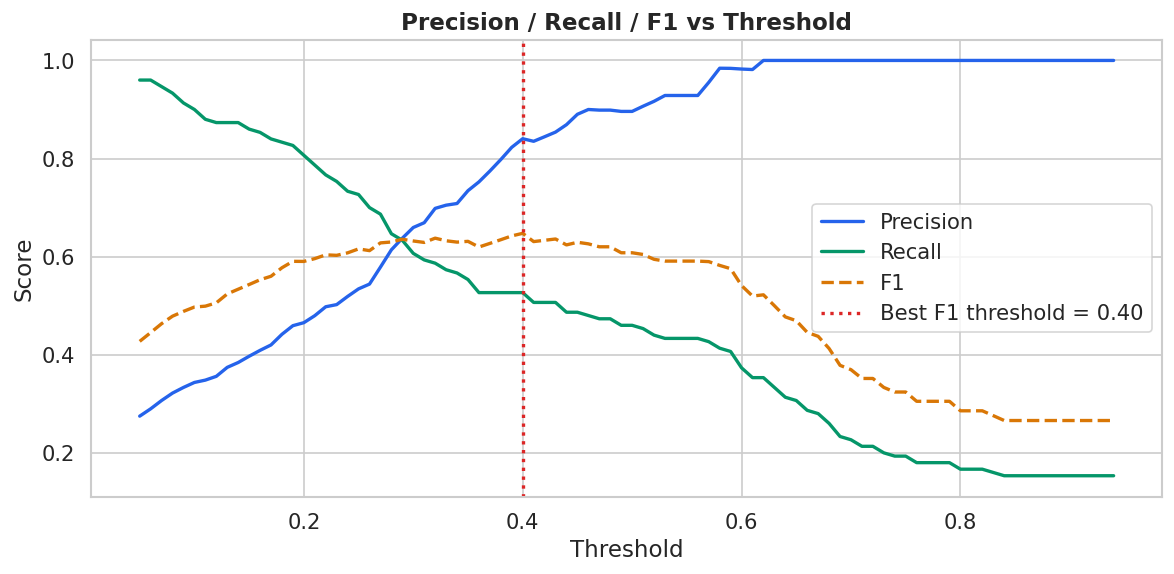

Best F1 threshold: 0.40  →  Recall: 0.527  Precision: 0.840  F1: 0.648


In [8]:
thresholds = np.arange(0.05, 0.95, 0.01)
rows = []
for t in thresholds:
    yp = (y_score >= t).astype(int)
    rows.append({'threshold': round(float(t), 2),
                 'precision': precision_score(y_true, yp, zero_division=0),
                 'recall':    recall_score(y_true, yp, zero_division=0),
                 'f1':        f1_score(y_true, yp, zero_division=0)})
thresh_df = pd.DataFrame(rows)
best_t    = thresh_df.loc[thresh_df['f1'].idxmax()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', color='#2563EB', lw=2)
ax.plot(thresh_df['threshold'], thresh_df['recall'],    label='Recall',    color='#059669', lw=2)
ax.plot(thresh_df['threshold'], thresh_df['f1'],        label='F1',        color='#D97706', lw=2, ls='--')
ax.axvline(best_t['threshold'], color='#DC2626', ls=':', lw=2,
           label=f"Best F1 threshold = {best_t['threshold']:.2f}")
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Best F1 threshold: {best_t['threshold']:.2f}  →  "
      f"Recall: {best_t['recall']:.3f}  Precision: {best_t['precision']:.3f}  F1: {best_t['f1']:.3f}")

## 7. Confusion Matrix at Best F1 Threshold

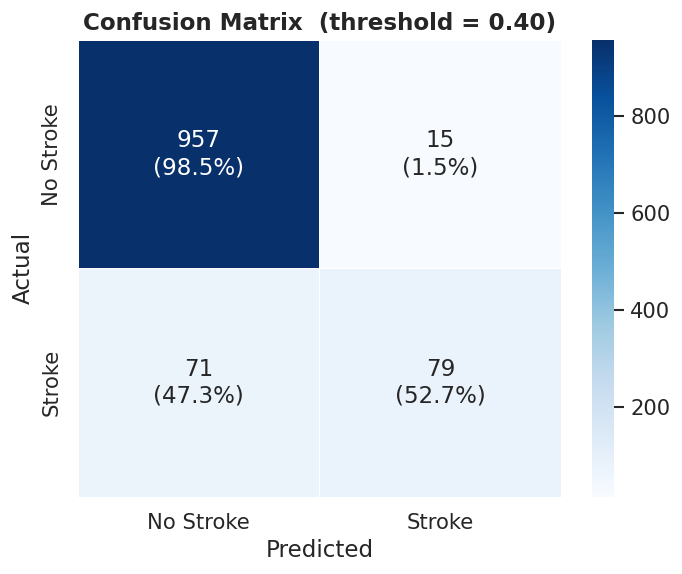

In [9]:
y_pred  = (y_score >= best_t['threshold']).astype(int)
cm      = confusion_matrix(y_true, y_pred)
cm_pct  = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
labels  = np.array([[f"{v}\n({p:.1f}%)" for v, p in zip(rv, rp)]
                    for rv, rp in zip(cm, cm_pct)])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'],
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix  (threshold = {best_t["threshold"]:.2f})', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. High-Risk Patient Profiles

In [10]:
result_df = test_df.copy()
result_df['stroke_probability'] = y_score
result_df['predicted_stroke']   = y_pred
result_df['actual_stroke']      = y_true

top_risk = result_df.sort_values('stroke_probability', ascending=False).head(10)
display(top_risk[['age','gender','hypertension','heart_disease',
                  'avg_glucose_level','bmi','smoking_status',
                  'stroke_probability','actual_stroke']].round(3))

,age,gender,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,stroke_probability,actual_stroke
318,64.1,Male,0,0,55.0,23.7,formerly smoked,0.991,1
798,74.6,Male,0,1,55.0,31.4,smokes,0.990,1
662,76.0,Female,0,0,55.0,25.7,never smoked,0.990,1
373,80.8,Female,0,0,55.0,33.1,Unknown,0.989,1
898,64.1,Male,0,0,55.0,26.7,formerly smoked,0.989,1
72,57.2,Female,0,0,55.0,27.9,never smoked,0.989,1
817,85.4,Male,0,0,55.0,21.6,Unknown,0.989,1
442,74.7,Male,1,1,55.0,17.7,Unknown,0.987,1
397,63.7,Male,1,0,55.0,29.1,formerly smoked,0.983,1
1094,54.7,Female,1,0,55.0,24.8,formerly smoked,0.981,1


## 9. False Negatives — Missed Strokes

Caught strokes (TP): 79  |  Missed strokes (FN): 71


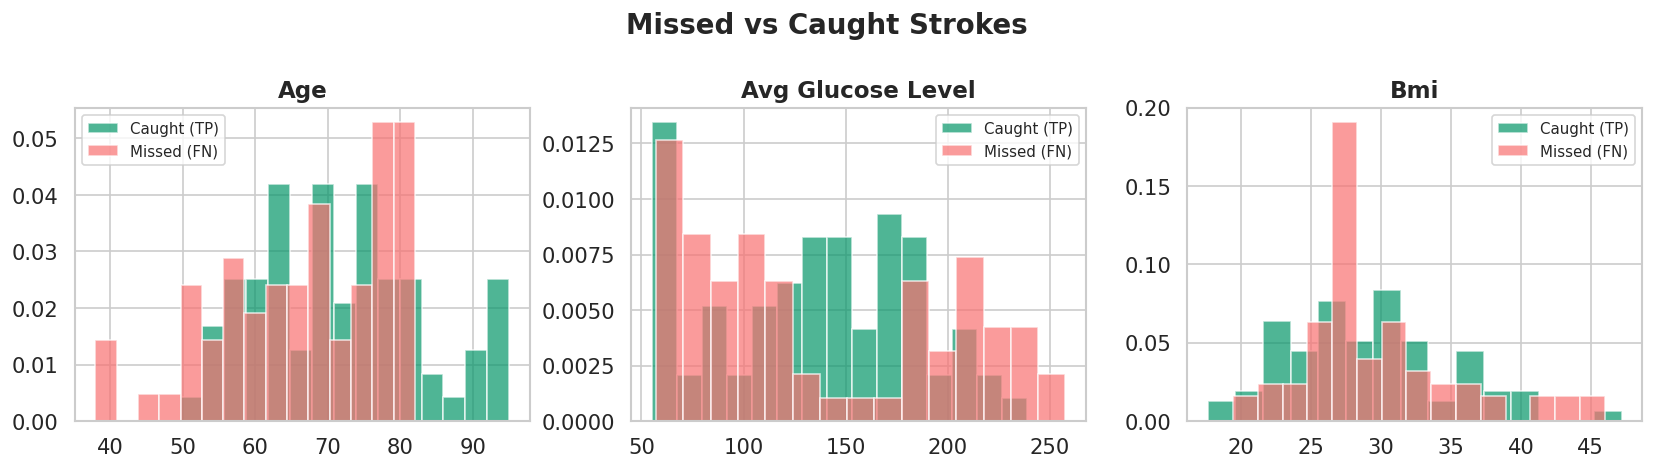

,age,gender,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,stroke_probability
26,61.0,Male,1,1,112.24,37.4,smokes,0.294
71,51.1,Male,0,0,64.10,35.4,Unknown,0.046
76,44.1,Male,0,0,172.96,23.3,formerly smoked,0.072
77,81.0,Female,0,1,78.70,19.4,Unknown,0.184
99,70.0,Female,0,0,57.20,37.8,Unknown,0.117
...,...,...,...,...,...,...,...,...
1015,51.0,Female,0,0,145.85,26.9,formerly smoked,0.269
1027,51.0,Male,1,0,186.27,43.0,smokes,0.156
1083,77.0,Female,0,0,105.22,31.0,never smoked,0.202
1098,40.0,Male,0,0,59.57,26.7,never smoked,0.024


In [11]:
fn_df = result_df[(result_df['actual_stroke'] == 1) & (result_df['predicted_stroke'] == 0)]
tp_df = result_df[(result_df['actual_stroke'] == 1) & (result_df['predicted_stroke'] == 1)]

print(f'Caught strokes (TP): {len(tp_df)}  |  Missed strokes (FN): {len(fn_df)}')

if len(fn_df) > 0 and len(tp_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, col in zip(axes, ['age', 'avg_glucose_level', 'bmi']):
        ax.hist(tp_df[col], bins=15, alpha=0.7, color='#059669', label='Caught (TP)', density=True)
        ax.hist(fn_df[col], bins=15, alpha=0.7, color='#F87171', label='Missed (FN)', density=True)
        ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
        ax.legend(fontsize=9)
    fig.suptitle('Missed vs Caught Strokes', fontweight='bold')
    plt.tight_layout()
    plt.show()

display(fn_df[['age','gender','hypertension','heart_disease',
               'avg_glucose_level','bmi','smoking_status',
               'stroke_probability']].round(3))

## 10. Stroke Probability by Age Group

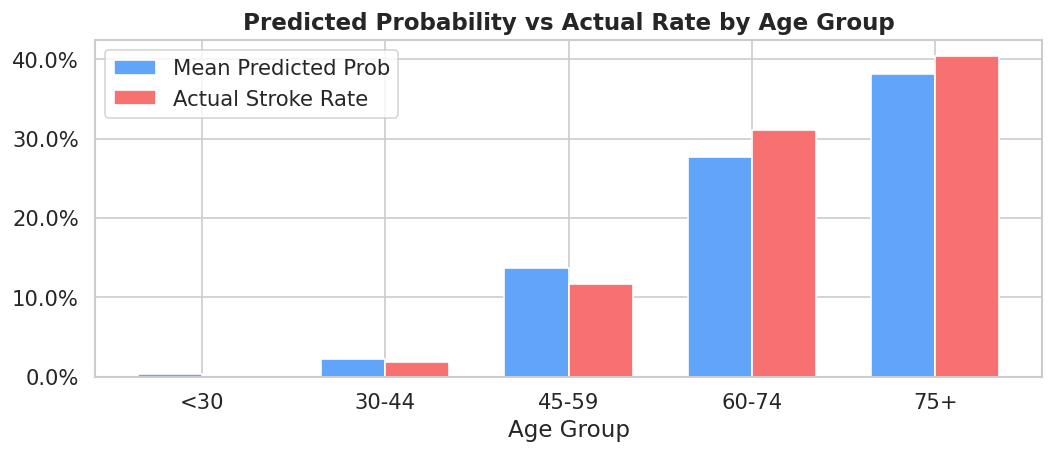

In [12]:
result_df['age_group'] = pd.cut(result_df['age'],
    bins=[0,30,45,60,75,120], labels=['<30','30-44','45-59','60-74','75+'])

age_stats = result_df.groupby('age_group', observed=True).agg(
    mean_prob=('stroke_probability','mean'),
    actual_rate=('actual_stroke','mean'),
    n=('actual_stroke','count')
).reset_index()

x, w = np.arange(len(age_stats)), 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, age_stats['mean_prob'],   width=w, color='#60A5FA', label='Mean Predicted Prob', edgecolor='white')
ax.bar(x + w/2, age_stats['actual_rate'], width=w, color='#F87171', label='Actual Stroke Rate',  edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(age_stats['age_group'])
ax.set_xlabel('Age Group')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Predicted Probability vs Actual Rate by Age Group', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Fairness & Subgroup Analysis

A model that performs well on average but poorly for a specific group can cause systematic harm in clinical use. Here we check ROC-AUC and actual stroke rate across demographic subgroups.

In [13]:
def subgroup_metrics(df, group_col):
    """Compute per-group ROC-AUC, actual stroke rate, and mean predicted probability."""
    rows = []
    for g, grp in df.groupby(group_col, observed=True):
        n      = len(grp)
        actual = grp['actual_stroke'].mean()
        mean_p = grp['stroke_probability'].mean()
        # Need both classes to compute AUC
        if grp['actual_stroke'].nunique() < 2:
            auc = float('nan')
        else:
            auc = roc_auc_score(grp['actual_stroke'], grp['stroke_probability'])
        rows.append({group_col: g, 'n': n, 'actual_stroke_rate': actual,
                     'mean_predicted_prob': mean_p, 'roc_auc': round(auc, 4)})
    return pd.DataFrame(rows)

gender_stats   = subgroup_metrics(result_df, 'gender')
age_fairness   = subgroup_metrics(result_df, 'age_group')
htn_stats      = subgroup_metrics(result_df, 'hypertension')
hd_stats       = subgroup_metrics(result_df, 'heart_disease')

print('── Gender ────────────────────────────────────────────────────')
display(gender_stats)
print('── Age Group ─────────────────────────────────────────────────')
display(age_fairness)
print('── Hypertension ──────────────────────────────────────────────')
display(htn_stats)
print('── Heart Disease ─────────────────────────────────────────────')
display(hd_stats)

── Gender ────────────────────────────────────────────────────


,gender,n,actual_stroke_rate,mean_predicted_prob,roc_auc
0,Female,658,0.133739,0.125454,0.9229
1,Male,464,0.133621,0.137384,0.9181


── Age Group ─────────────────────────────────────────────────


,age_group,n,actual_stroke_rate,mean_predicted_prob,roc_auc
0,<30,328,0.000000,0.003359,NaN
1,30-44,214,0.018692,0.021616,0.6464
2,45-59,240,0.116667,0.136241,0.8032
3,60-74,209,0.311005,0.277243,0.8474
4,75+,131,0.404580,0.381114,0.7762


── Hypertension ──────────────────────────────────────────────


,hypertension,n,actual_stroke_rate,mean_predicted_prob,roc_auc
0,0,996,0.113454,0.109197,0.9303
1,1,126,0.293651,0.297898,0.8081


── Heart Disease ─────────────────────────────────────────────


,heart_disease,n,actual_stroke_rate,mean_predicted_prob,roc_auc
0,0,1048,0.114504,0.116220,0.9219
1,1,74,0.405405,0.331039,0.8091


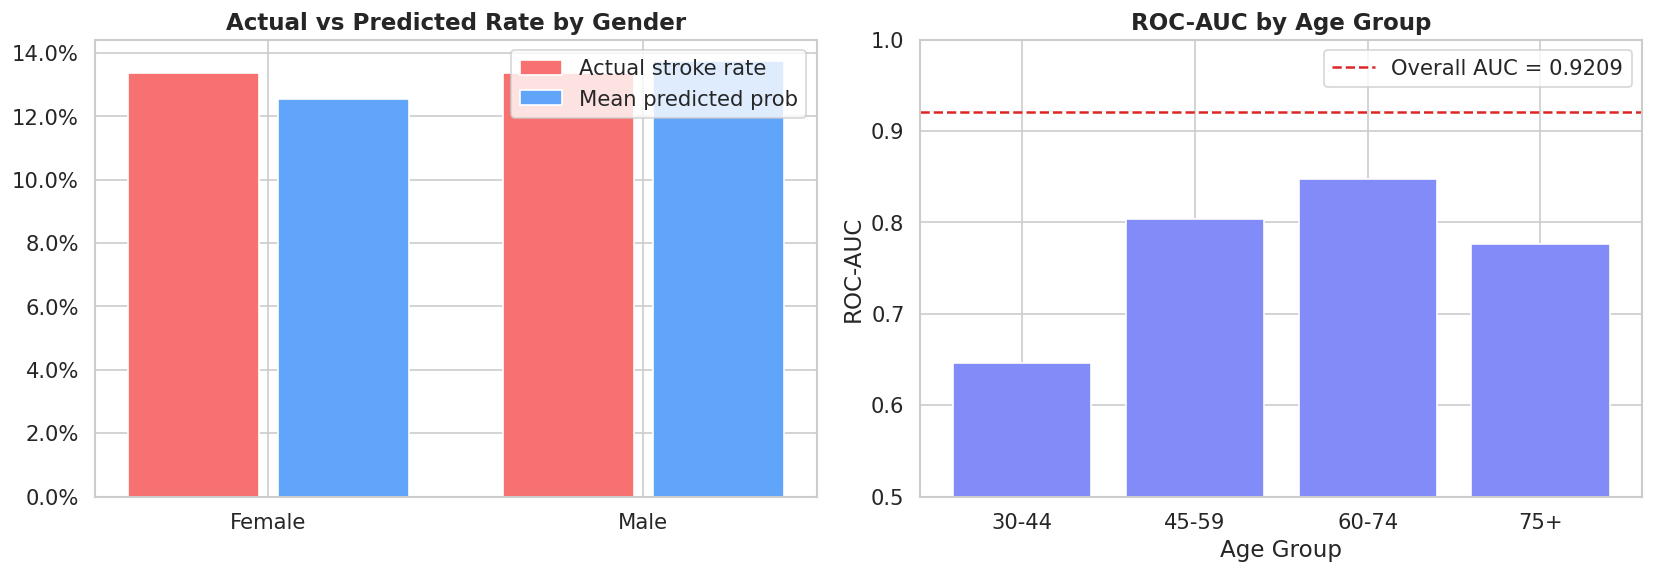


Age group AUC range: 0.6464 – 0.8474  (gap = 0.2010)
Gender AUC range:     0.9181 – 0.9229  (gap = 0.0048)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gender: actual vs predicted rates ─────────────────────────────────────────
x_g = np.arange(len(gender_stats))
axes[0].bar(x_g - 0.2, gender_stats['actual_stroke_rate'],  0.35, color='#F87171', label='Actual stroke rate')
axes[0].bar(x_g + 0.2, gender_stats['mean_predicted_prob'], 0.35, color='#60A5FA', label='Mean predicted prob')
axes[0].set_xticks(x_g)
axes[0].set_xticklabels(gender_stats['gender'])
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title('Actual vs Predicted Rate by Gender', fontweight='bold')
axes[0].legend()

# ── Age Group: ROC-AUC per group ───────────────────────────────────────────────
valid = age_fairness.dropna(subset=['roc_auc'])
axes[1].bar(valid['age_group'].astype(str), valid['roc_auc'],
            color='#818CF8', edgecolor='white')
axes[1].axhline(roc_auc_score(y_true, y_score), color='#DC2626',
                ls='--', lw=1.5, label=f'Overall AUC = {roc_auc_score(y_true, y_score):.4f}')
axes[1].set_ylim(0.5, 1.0)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC by Age Group', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Disparity summary ──────────────────────────────────────────────────────────
valid_auc = age_fairness['roc_auc'].dropna()
print(f"\nAge group AUC range: {valid_auc.min():.4f} – {valid_auc.max():.4f}  "
      f"(gap = {valid_auc.max() - valid_auc.min():.4f})")
g_auc = gender_stats['roc_auc'].dropna()
if len(g_auc) >= 2:
    print(f"Gender AUC range:     {g_auc.min():.4f} – {g_auc.max():.4f}  "
          f"(gap = {g_auc.max() - g_auc.min():.4f})")

## 12. Business Cost Analysis

ROC-AUC tells you how well the model ranks patients — but a hospital cares about **cost**, not ranking.  

In stroke screening, the two error types have very different real-world consequences:

| Error | Clinical meaning | Relative cost |
|-------|-----------------|---------------|
| **False Negative (FN)** | Missed stroke — patient sent home without intervention | High |
| **False Positive (FP)** | Unnecessary alert — extra tests, clinician time, patient anxiety | Low |

We sweep the decision threshold and find the point that **minimises total expected cost**.

In [15]:
# ── Cost parameters ────────────────────────────────────────────────────────────
# Adjust these to match your clinical context.
# A 10:1 ratio means missing a stroke is 10× more costly than a false alarm.
COST_FN = 10   # cost of missing a stroke (false negative)
COST_FP = 1    # cost of an unnecessary alert (false positive)

cost_rows = []
for t in np.arange(0.01, 0.99, 0.01):
    yp = (y_score >= t).astype(int)
    cm_t = confusion_matrix(y_true, yp, labels=[0, 1])
    tn, fp, fn, tp = cm_t.ravel()
    total_cost = fn * COST_FN + fp * COST_FP
    cost_rows.append({
        'threshold': round(float(t), 2),
        'total_cost': total_cost,
        'fn': fn, 'fp': fp, 'tp': tp, 'tn': tn,
        'recall':    recall_score(y_true, yp, zero_division=0),
        'precision': precision_score(y_true, yp, zero_division=0),
    })

cost_df   = pd.DataFrame(cost_rows)
best_cost = cost_df.loc[cost_df['total_cost'].idxmin()]

print(f'Cost ratio  FN:{COST_FP} = {COST_FN}:1')
print(f'\nOptimal threshold (min cost): {best_cost["threshold"]:.2f}')
print(f'  Total cost : {best_cost["total_cost"]:.0f}')
print(f'  FN (missed): {best_cost["fn"]:.0f}  |  FP (false alarms): {best_cost["fp"]:.0f}')
print(f'  Recall     : {best_cost["recall"]:.3f}  |  Precision: {best_cost["precision"]:.3f}')

Cost ratio  FN:1 = 10:1

Optimal threshold (min cost): 0.08
  Total cost : 395
  FN (missed): 10  |  FP (false alarms): 295
  Recall     : 0.933  |  Precision: 0.322


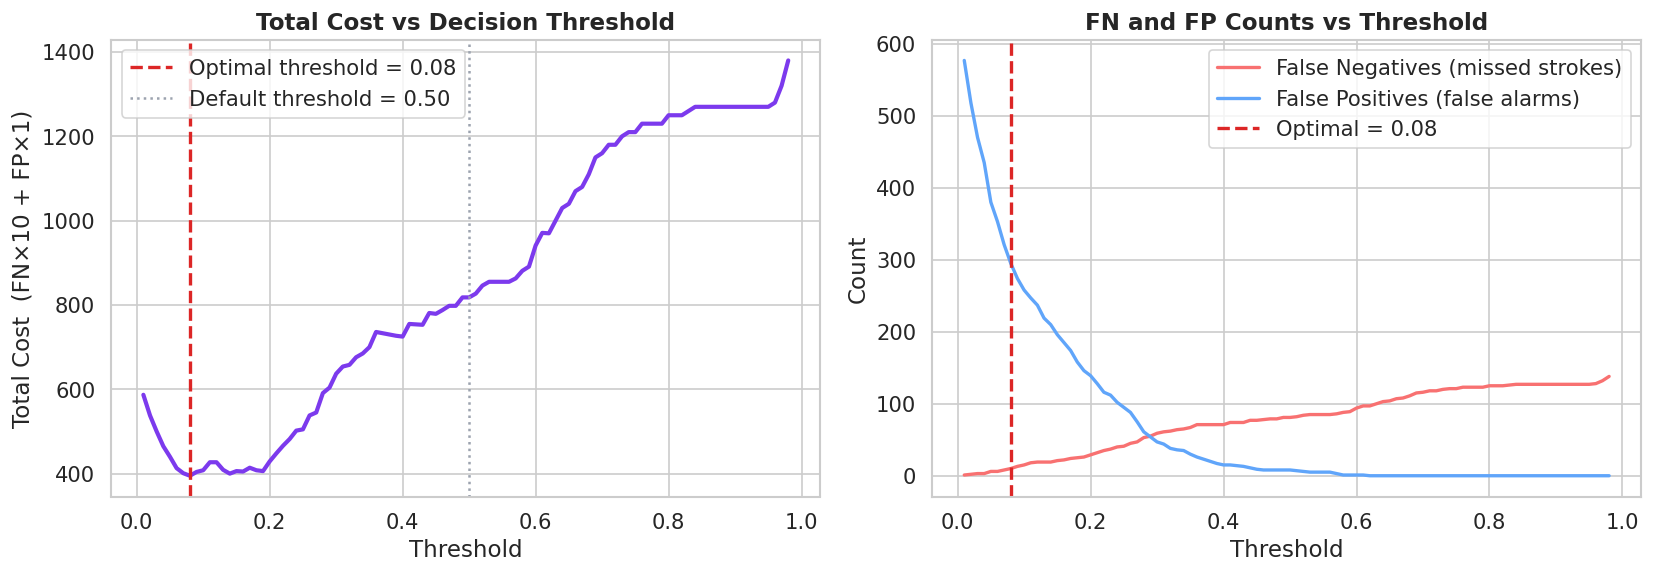


── Threshold Comparison ──────────────────────────────────────


,Threshold,FN (missed strokes),FP (false alarms),Recall,Precision,Total Cost
label,,,,,,
Default (0.50),0.50,81,8,0.460,0.896,818
Optimal (0.08),0.08,10,295,0.933,0.322,395



Switching to optimal threshold saves 423 cost units (51.7% reduction).


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Total cost vs threshold ────────────────────────────────────────────────────
axes[0].plot(cost_df['threshold'], cost_df['total_cost'], color='#7C3AED', lw=2.5)
axes[0].axvline(best_cost['threshold'], color='#DC2626', ls='--', lw=2,
                label=f'Optimal threshold = {best_cost["threshold"]:.2f}')
axes[0].axvline(0.5, color='#9CA3AF', ls=':', lw=1.5, label='Default threshold = 0.50')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel(f'Total Cost  (FN×{COST_FN} + FP×{COST_FP})')
axes[0].set_title('Total Cost vs Decision Threshold', fontweight='bold')
axes[0].legend()

# ── FN and FP counts vs threshold ─────────────────────────────────────────────
axes[1].plot(cost_df['threshold'], cost_df['fn'], color='#F87171', lw=2, label='False Negatives (missed strokes)')
axes[1].plot(cost_df['threshold'], cost_df['fp'], color='#60A5FA', lw=2, label='False Positives (false alarms)')
axes[1].axvline(best_cost['threshold'], color='#DC2626', ls='--', lw=2,
                label=f'Optimal = {best_cost["threshold"]:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Count')
axes[1].set_title('FN and FP Counts vs Threshold', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Side-by-side comparison: default vs optimal threshold ─────────────────────
default_row = cost_df[cost_df['threshold'] == 0.50].iloc[0]
comparison = pd.DataFrame([
    {'Threshold': 0.50,                       'label': 'Default (0.50)',
     'FN (missed strokes)': int(default_row['fn']),
     'FP (false alarms)':   int(default_row['fp']),
     'Recall': default_row['recall'], 'Precision': default_row['precision'],
     'Total Cost': int(default_row['total_cost'])},
    {'Threshold': best_cost['threshold'],     'label': f'Optimal ({best_cost["threshold"]:.2f})',
     'FN (missed strokes)': int(best_cost['fn']),
     'FP (false alarms)':   int(best_cost['fp']),
     'Recall': best_cost['recall'], 'Precision': best_cost['precision'],
     'Total Cost': int(best_cost['total_cost'])},
]).set_index('label')

print('\n── Threshold Comparison ──────────────────────────────────────')
display(comparison.round(3))

cost_saved = int(default_row['total_cost']) - int(best_cost['total_cost'])
print(f'\nSwitching to optimal threshold saves {cost_saved} cost units '
      f'({100*cost_saved/default_row["total_cost"]:.1f}% reduction).')